In [1]:
import torch
import torchphysics as tp
X = tp.spaces.R1('x')
Y = tp.spaces.R1('y')
Z = tp.spaces.R1("z")
U = tp.spaces.R1('u')
V = tp.spaces.R1('v')
W = tp.spaces.R1('w')
URMS = tp.spaces.R1('urms')
VRMS = tp.spaces.R1('vrms')
WRMS = tp.spaces.R1('wrms')
UV=tp.spaces.R1('uv')
UW=tp.spaces.R1('uw')
VW=tp.spaces.R1('vw')
P=tp.spaces.R1('p')

/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import numpy as np

In [3]:
class Turbulent_Data(torch.utils.data.Dataset):
    def __init__(self,data_DF,x_list,y_list,Nsamples=30):
        self.x_train=data_DF[x_list].values
        self.y_train=data_DF[y_list].values
        self.N_iter=Nsamples
        self.ids=random.sample(range(len(data_DF)),self.N_iter)
        self.counter=0
    def __len__(self):
        return len(self.y_train)

    def __getitem__(self,idx):
        if idx>self.N_iter:
            raise StopIteration
        #return self.x_train[idx] , self.y_train[idx]
        #print(torch.as_tensor([self.x_train[idx]]).shape)
        if self.counter>(self.N_iter):
            self.counter=0
            self.ids=random.sample(range(len(self.x_train)),self.N_iter)
        idx_local=self.ids[idx]
        #idx_local=idx
        P_xtrain=tp.spaces.Points([self.x_train[idx_local]],X*Y*Z,dtype=torch.float32)
        P_ytrain=tp.spaces.Points([self.y_train[idx_local]],U*V*W*URMS*VRMS*WRMS*UV*UW*VW,dtype=torch.float32)
        self.counter+=1
        return P_xtrain,P_ytrain

In [4]:
class Turbulent_Data_local(torch.utils.data.Dataset):
    def __init__(self,data_DF,x_list,y_list,Nsamples=451):
        self.x_positions=data_DF["x"].unique()
        self.data=data_DF
        #self.x_train=torch.tensor(x_train,dtype=torch.float32)
        #self.y_train=torch.tensor(y_train,dtype=torch.float32)
        #self.x_train=tp.spaces.Points(self.x_train,X*Y)
        #self.y_train=tp.spaces.Points(self.y_train,U*V)
        self.N_iter=Nsamples
        self.local=random.sample(self.x_positions,1)
        self.x_train=data_DF[data_DF["x"]==self.local][x_list].values
        self.y_train=data_DF[data_DF["x"]==self.local][y_list].values
    def __len__(self):
        return len(self.y_train)

    def __getitem__(self,idx):
        if idx>self.N_iter:
            raise StopIteration
        #return self.x_train[idx] , self.y_train[idx]
        #print(torch.as_tensor([self.x_train[idx]]).shape)
        #idx_local=np.random.randint(0,len(self.y_train)-1)
        idx_local=idx
        P_xtrain=tp.spaces.Points([self.x_train[idx_local]],X*Y,dtype=torch.float32)
        P_ytrain=tp.spaces.Points([self.y_train[idx_local]],U*V*URMS*VRMS*UV,dtype=torch.float32)
        return P_xtrain,P_ytrain

In [5]:
class Ho_Turbulent_Data(torch.utils.data.Dataset):
    def __init__(self,data_DF,x_list,y_list,horizon_sampler,Nsamples=30):
        self.x_train=data_DF[x_list].values
        self.y_train=data_DF[y_list].values
        self.sampler=horizon_sampler
        self.N_iter=Nsamples
        #self.x_train=torch.tensor(x_train,dtype=torch.float32)
        #self.y_train=torch.tensor(y_train,dtype=torch.float32)
        #self.x_train=tp.spaces.Points(self.x_train,X*Y)
        #self.y_train=tp.spaces.Points(self.y_train,U*V)
    def __len__(self):
        return len(self.y_train)

    def __getitem__(self,idx):
        if idx>self.N_iter:
            raise StopIteration
        x_horizon= self.sampler.sample_points(device="cpu")
        x_horizon,_=x_horizon.track_coord_gradients()
        x_horizon=x_horizon["x"].detach().numpy()
        #print(x_horizon)
        idx_local=np.random.randint(0,len(self.y_train)-1)
        y_new=np.broadcast_to(self.x_train[idx_local],(x_horizon.shape[0],self.x_train[idx_local].shape[0]))
        target_new=np.broadcast_to(self.y_train[idx_local],(x_horizon.shape[0],self.y_train[idx_local].shape[0]))
        X_points = np.concatenate((x_horizon,y_new),axis=1)
        P_xtrain=tp.spaces.Points([X_points],X*Y,dtype=torch.float32)
        P_ytrain=tp.spaces.Points([target_new],U*V*URMS*VRMS*UV,dtype=torch.float32)
        return P_xtrain,P_ytrain

In [6]:
class Rn_Turbulent_Data(torch.utils.data.Dataset):
    def __init__(self,data_DF,x_list,y_list,max_it):
        self.x_train=data_DF[x_list].values
        self.y_train=data_DF[y_list].values
        self.length=min(max_it,len(self.y_train))
        #self.x_train=torch.tensor(x_train,dtype=torch.float32)
        #self.y_train=torch.tensor(y_train,dtype=torch.float32)
        #self.x_train=tp.spaces.Points(self.x_train,X*Y)
        #self.y_train=tp.spaces.Points(self.y_train,U*V)
    def __len__(self):
        return self.length

    def __getitem__(self,idx):
        #return self.x_train[idx] , self.y_train[idx]
        #print(torch.as_tensor([self.x_train[idx]]).shape)
        id_random=random.randint(0,len(self.y_train))
        P_xtrain=tp.spaces.Points([self.x_train[id_random]],X*Y,dtype=torch.float32)
        P_ytrain=tp.spaces.Points([self.y_train[id_random]],U*V*URMS*VRMS*UV,dtype=torch.float32)
        return P_xtrain,P_ytrain

In [7]:
DF_Data=pd.read_csv("Data/Flow_2289_C20_3Ddomain.csv")

In [8]:
DF_Data["V"]=DF_Data["V"]*50

In [9]:
DF_Data["z"]=DF_Data["z"]+0.6

In [10]:
DF_Data=DF_Data[DF_Data["z"]<=0.1]

In [11]:
DF_Data

,x,y,z,U,V,W,urms,vrms,wrms,uv,uw,vw
0,0.0,0.000000,0.00000,2.600700e-15,-1.846450e-16,-3.943500e-17,2.140100e-13,8.048000e-16,1.041400e-14,1.577900e-29,-1.218300e-28,-2.550300e-31
1,0.0,0.009732,0.00000,1.252400e-05,1.089550e-03,-1.180100e-05,5.116400e-02,1.570100e-02,3.865200e-02,3.013900e-04,4.343400e-04,-1.474400e-04
2,0.0,0.038738,0.00000,3.565800e-04,4.114250e-03,-3.949400e-06,2.368600e-01,1.437300e-01,8.322600e-02,6.545700e-03,4.735100e-03,2.250800e-03
3,0.0,0.086455,0.00000,6.890800e-01,1.204050e+00,3.764700e-02,1.652700e+00,7.969400e-01,1.177300e+00,1.087300e+00,5.415400e-02,8.468100e-02
4,0.0,0.151950,0.00000,1.083300e+00,1.229900e-01,1.852300e-02,1.520500e+00,8.887900e-01,1.140800e+00,1.101300e+00,-1.085800e-02,-1.397800e-01
...,...,...,...,...,...,...,...,...,...,...,...,...
1651,3.5,1.809000,0.08333,1.182400e+00,8.208500e-01,1.333800e-02,1.550800e+00,8.840400e-01,1.090200e+00,-1.037000e+00,6.357600e-02,2.783500e-02
1652,3.5,1.882900,0.08333,8.647800e-01,6.358500e-01,3.058800e-02,1.754200e+00,9.303000e-01,1.220700e+00,-1.333300e+00,-1.919200e-01,-9.279500e-02
1653,3.5,1.939700,0.08333,4.644200e-01,1.473600e+00,-7.312700e-02,1.330000e+00,7.583300e-01,1.273400e+00,-6.345800e-01,-4.673200e-01,4.775000e-01
1654,3.5,1.978100,0.08333,1.637700e-02,3.664100e-01,-1.362700e-02,3.133900e-01,1.966400e-01,3.707700e-01,-8.791600e-03,-1.216700e-01,-5.305900e-02


In [12]:
DF_Data["x"].unique()

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
       2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5])

In [13]:
import random
def Augment_1D_data(DF,Nsampler,L_x):
    DF_out=DF[0:0]
    for _ in range(Nsampler):
        Ny=random.randint(0, len(DF)-1)
        DF_temp=DF.iloc[[Ny]]
        DF_temp["x"]=random.uniform(0,L_x)
        DF_out=pd.concat([DF_out,DF_temp],ignore_index=True)
    return DF_out

        

In [14]:
torch.cuda.device_count()

0

In [15]:
X_interval = tp.domains.Interval(X, 0, 3.6) # <-add the bounds of the Interval (0, 2)
Y_interval = tp.domains.Interval(Y, 0, 2.0)
Z_interval = tp.domains.Interval(Z, 0, 0.1)
Sim_domain = X_interval*Y_interval*Z_interval

Y_interval_sub_low=tp.domains.Interval(Y, 0, 0.08)
Sim_domain_sub_low=X_interval*Y_interval_sub_low*Z_interval
Y_interval_sub_up=tp.domains.Interval(Y, 2-0.08, 2)
Sim_domain_sub_up=X_interval*Y_interval_sub_up*Z_interval

In [16]:
#DF_out=Augment_1D_data(DF_Data,8000,2.0)
ho_sampler = tp.samplers.RandomUniformSampler(X_interval, n_points=200)


In [17]:

bound_sampler_low = tp.samplers.RandomUniformSampler(Y_interval.boundary_left*X_interval*Z_interval, n_points=250)

bound_sampler_up = tp.samplers.RandomUniformSampler(X_interval*Y_interval.boundary*Z_interval, n_points=500)


In [18]:
DF_DIST=pd.read_csv("Data/dist_2289_3D.csv")

In [19]:
x_corr=DF_DIST["x"].unique()
x_corr=torch.tensor(x_corr,requires_grad=False)
z_corr=DF_DIST["z"].unique()
z_corr=torch.tensor(z_corr,requires_grad=False)

dist=DF_DIST["dist"].to_numpy()
dist=np.reshape(dist,(len(z_corr),len(x_corr)))
dist=np.transpose(dist)
dist=torch.tensor(dist,requires_grad=False)

torch.Size([720, 288])

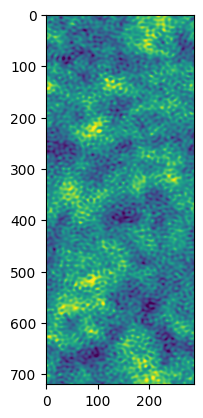

In [20]:
import matplotlib.pyplot as plt
plt.imshow(dist)
dist.shape

In [21]:
DF_Data

,x,y,z,U,V,W,urms,vrms,wrms,uv,uw,vw
0,0.0,0.000000,0.00000,2.600700e-15,-1.846450e-16,-3.943500e-17,2.140100e-13,8.048000e-16,1.041400e-14,1.577900e-29,-1.218300e-28,-2.550300e-31
1,0.0,0.009732,0.00000,1.252400e-05,1.089550e-03,-1.180100e-05,5.116400e-02,1.570100e-02,3.865200e-02,3.013900e-04,4.343400e-04,-1.474400e-04
2,0.0,0.038738,0.00000,3.565800e-04,4.114250e-03,-3.949400e-06,2.368600e-01,1.437300e-01,8.322600e-02,6.545700e-03,4.735100e-03,2.250800e-03
3,0.0,0.086455,0.00000,6.890800e-01,1.204050e+00,3.764700e-02,1.652700e+00,7.969400e-01,1.177300e+00,1.087300e+00,5.415400e-02,8.468100e-02
4,0.0,0.151950,0.00000,1.083300e+00,1.229900e-01,1.852300e-02,1.520500e+00,8.887900e-01,1.140800e+00,1.101300e+00,-1.085800e-02,-1.397800e-01
...,...,...,...,...,...,...,...,...,...,...,...,...
1651,3.5,1.809000,0.08333,1.182400e+00,8.208500e-01,1.333800e-02,1.550800e+00,8.840400e-01,1.090200e+00,-1.037000e+00,6.357600e-02,2.783500e-02
1652,3.5,1.882900,0.08333,8.647800e-01,6.358500e-01,3.058800e-02,1.754200e+00,9.303000e-01,1.220700e+00,-1.333300e+00,-1.919200e-01,-9.279500e-02
1653,3.5,1.939700,0.08333,4.644200e-01,1.473600e+00,-7.312700e-02,1.330000e+00,7.583300e-01,1.273400e+00,-6.345800e-01,-4.673200e-01,4.775000e-01
1654,3.5,1.978100,0.08333,1.637700e-02,3.664100e-01,-1.362700e-02,3.133900e-01,1.966400e-01,3.707700e-01,-8.791600e-03,-1.216700e-01,-5.305900e-02


In [22]:
def pop_data_in_IBM(DF,dist,x_corr):
    row=0
    DF_new=DF
    while row<=len(DF)-1:
        position_r=sum(x_corr<DF_new["x"][row])-1
        position_l=position_r-1
        height=dist[position_l]+(dist[position_r]-dist[position_l])*(DF_new["x"][row]-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
        if (DF_new["y"][row]<=height) or (DF_new["y"][row]>=2-height):
            print(DF_new["y"][row])
            DF_new.iloc[row][["U","V","urms","vrms","uv"]]=0
        row+=1
    DF_new.reset_index()
    return DF_new

In [23]:
#DF_processed=pop_data_in_IBM(DF_Data,dist,x_corr)
DF_processed=DF_Data

In [24]:
DF_processed.head(50)

,x,y,z,U,V,W,urms,vrms,wrms,uv,uw,vw
0,0.0,0.000000,0.0,2.600700e-15,-1.846450e-16,-3.943500e-17,2.140100e-13,8.048000e-16,1.041400e-14,1.577900e-29,-1.218300e-28,-2.550300e-31
1,0.0,0.009732,0.0,1.252400e-05,1.089550e-03,-1.180100e-05,5.116400e-02,1.570100e-02,3.865200e-02,3.013900e-04,4.343400e-04,-1.474400e-04
2,0.0,0.038738,0.0,3.565800e-04,4.114250e-03,-3.949400e-06,2.368600e-01,1.437300e-01,8.322600e-02,6.545700e-03,4.735100e-03,2.250800e-03
3,0.0,0.086455,0.0,6.890800e-01,1.204050e+00,3.764700e-02,1.652700e+00,7.969400e-01,1.177300e+00,1.087300e+00,5.415400e-02,8.468100e-02
4,0.0,0.151950,0.0,1.083300e+00,1.229900e-01,1.852300e-02,1.520500e+00,8.887900e-01,1.140800e+00,1.101300e+00,-1.085800e-02,-1.397800e-01
5,0.0,0.233960,0.0,1.296100e+00,1.379700e-01,6.954000e-03,1.437400e+00,8.687300e-01,1.020700e+00,9.720600e-01,1.626400e-02,-4.361100e-02
6,0.0,0.330870,0.0,1.443400e+00,-7.985500e-02,-2.129100e-03,1.377700e+00,8.291000e-01,9.509900e-01,8.426300e-01,4.404400e-02,-2.340300e-02
7,0.0,0.440810,0.0,1.581500e+00,-3.005500e-02,-3.577000e-03,1.284500e+00,7.903100e-01,9.036900e-01,7.193300e-01,-4.455900e-02,-5.289100e-02
8,0.0,0.561630,0.0,1.707100e+00,8.486500e-02,-1.285200e-02,1.104000e+00,7.247900e-01,8.191300e-01,4.964400e-01,1.259100e-01,2.521400e-02
9,0.0,0.690980,0.0,1.818800e+00,1.435750e-01,-1.075300e-02,9.650100e-01,6.365500e-01,6.707300e-01,3.774600e-01,4.157000e-02,2.394600e-02


In [25]:
dataset_turbulent=Turbulent_Data(DF_processed,["x","y","z"],["U","V","W","urms","vrms","wrms","uv","uw","vw"],len(DF_processed))

In [26]:
def IBM_irr_filter_up(x,z,y):
    position_r=np.array([sum(x_corr<x_i)-1 for x_i in x])
    position_r_z=np.array([sum(x_corr<z_i)-1 for z_i in z])
    #position_r=sum(x_corr<x)
    position_l=position_r-1
    position_l_z=position_r_z-1
    x_new=torch.transpose(x,1,0)[0]
    z_new=torch.transpose(z,1,0)[0]
    height_l=dist[position_l,position_l_z]+(dist[position_r,position_l_z]-dist[position_l,position_l_z])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    height_r=dist[position_l,position_r_z]+(dist[position_r,position_r_z]-dist[position_l,position_r_z])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    height=height_l+(height_r-height_l)*(z_new-z_corr[position_l_z])/(z_corr[position_r_z]-z_corr[position_l_z])
    return (y[...,0]>=2-height)   
def IBM_irr_filter_low(x,y,z):
    position_r=np.array([sum(x_corr<x_i)-1 for x_i in x])
    position_r_z=np.array([sum(x_corr<z_i)-1 for z_i in z])
    #position_r=sum(x_corr<x)
    position_l=position_r-1
    position_l_z=position_r_z-1
    x_new=torch.transpose(x,1,0)[0]
    z_new=torch.transpose(z,1,0)[0]
    height_l=dist[position_l,position_l_z]+(dist[position_r,position_l_z]-dist[position_l,position_l_z])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    height_r=dist[position_l,position_r_z]+(dist[position_r,position_r_z]-dist[position_l,position_r_z])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    height=height_l+(height_r-height_l)*(z_new-z_corr[position_l_z])/(z_corr[position_r_z]-z_corr[position_l_z])
    return (y[...,0]<=height)
IBM_sampler_irr_low = tp.samplers.RandomUniformSampler(Sim_domain_sub_low,n_points=1000,filter_fn=IBM_irr_filter_low).make_static(resample_interval=2000)
IBM_sampler_irr_up = tp.samplers.RandomUniformSampler(Sim_domain_sub_up,n_points=1000,filter_fn=IBM_irr_filter_up).make_static(resample_interval=2000)

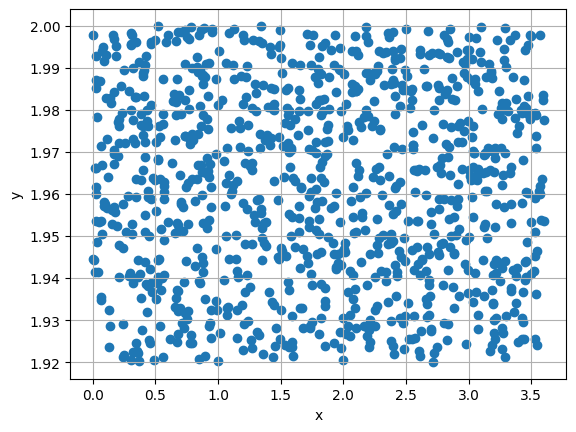

In [27]:
Omega_sampler = tp.samplers.RandomUniformSampler(Sim_domain, n_points=500)
plot           = tp.utils.scatter(X*Y, IBM_sampler_irr_up)

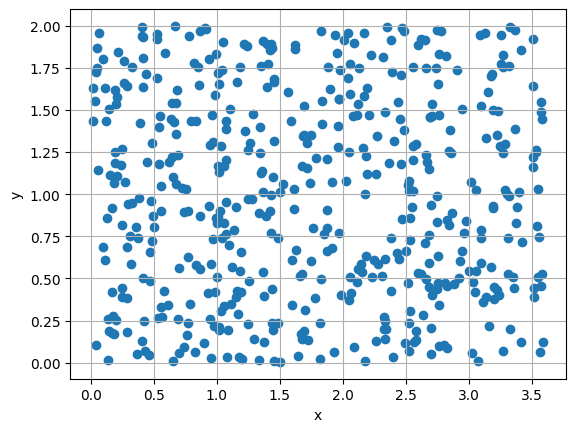

In [28]:
Omega_sampler = tp.samplers.RandomUniformSampler(Sim_domain, n_points=500)
plot           = tp.utils.scatter(X*Y, Omega_sampler)

In [29]:
def IBM_filter(x,y):
    return y[...,0]<=torch.sin(x[...,0]*np.pi*2)*0.1    
IBM_sampler_ = tp.samplers.RandomUniformSampler(Sim_domain,n_points=1000,filter_fn=IBM_filter)

In [30]:
def IBM_filter_2(y):
    return (y[...,0]<0)&(y[...,0]>-0.1)
    
IBM_sampler_2 = tp.samplers.RandomUniformSampler(Sim_domain,n_points=1000,filter_fn=IBM_filter_2)

In [31]:
def Inner_filter(x,z,y):
    position_r=np.array([sum(x_corr<x_i)-1 for x_i in x])
    position_r_z=np.array([sum(x_corr<z_i)-1 for z_i in z])
    #position_r=sum(x_corr<x)
    position_l=position_r-1
    position_l_z=position_r_z-1
    x_new=torch.transpose(x,1,0)[0]
    z_new=torch.transpose(z,1,0)[0]
    height_l=dist[position_l,position_l_z]+(dist[position_r,position_l_z]-dist[position_l,position_l_z])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    height_r=dist[position_l,position_r_z]+(dist[position_r,position_r_z]-dist[position_l,position_r_z])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    height=height_l+(height_r-height_l)*(z_new-z_corr[position_l_z])/(z_corr[position_r_z]-z_corr[position_l_z])
    return (y[...,0]>height) |(y[...,0]<2-height)   
inner_sampler = tp.samplers.RandomUniformSampler(Sim_domain, n_points=5000).make_static(resample_interval=2000)#,filter_fn=Inner_filter)

In [32]:
def self_sin(input):
    return input.sin()
def self_cos(input):
    return input.cos()

In [33]:
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(seed=42)
class FCN_model_Fourier_Feature(nn.Module):
    def __init__(self,input_space,output_space,N_features,sigma_1=1,sigma_2=15):
        super().__init__()
        self.W_1 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32) * sigma_1, dtype=torch.float32, requires_grad=False)
        self.W_2 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32) * sigma_2, dtype=torch.float32, requires_grad=False)
        self.register_buffer("selfW1", self.W_1, persistent=False)
        self.register_buffer("selfW2", self.W_2, persistent=False)
        self.output_space=output_space
        self.fc1_l=nn.Linear(in_features=N_features,out_features=150)
        self.fc2_l=nn.Linear(in_features=150,out_features=150)
        self.fc3_l=nn.Linear(in_features=150,out_features=150)
        self.fc4_l=nn.Linear(in_features=150,out_features=150)
        self.fc5_l=nn.Linear(in_features=150,out_features=150)
        self.fc6_l=nn.Linear(in_features=150,out_features=150)
        self.fc7_l=nn.Linear(in_features=150,out_features=150)
        ###
        self.fc1_r=nn.Linear(in_features=N_features,out_features=150)
        self.fc2_r=nn.Linear(in_features=150,out_features=150)
        self.fc3_r=nn.Linear(in_features=150,out_features=150)
        self.fc4_r=nn.Linear(in_features=150,out_features=150)
        self.fc5_r=nn.Linear(in_features=150,out_features=150)
        self.fc6_r=nn.Linear(in_features=150,out_features=150)
        self.fc7_r=nn.Linear(in_features=150,out_features=150)
        
        self.out=nn.Linear(in_features=N_features,out_features=output_space.dim)
    def forward(self,t):
        t_1=torch.concat((self_sin(torch.matmul(t,self.W_1)),self_cos(torch.matmul(t,self.W_1))),1)
        t_1=F.tanh(self.fc1_l(t_1))
        t_1=F.tanh(self.fc2_l(t_1))
        t_1=F.tanh(self.fc2_l(t_1))
        t_1=F.tanh(self.fc3_l(t_1))
        t_1=F.tanh(self.fc4_l(t_1))
        t_1=F.tanh(self.fc5_l(t_1))
        t_1=F.tanh(self.fc6_l(t_1))
        t_1=F.tanh(self.fc7_l(t_1))
        t_2=torch.concat((self_sin(torch.matmul(t,self.W_2)),self_cos(torch.matmul(t,self.W_2))),1)
        t_2=F.tanh(self.fc1_r(t_2))
        t_2=F.tanh(self.fc2_r(t_2))
        t_2=F.tanh(self.fc2_r(t_2))
        t_2=F.tanh(self.fc3_r(t_2))
        t_2=F.tanh(self.fc4_r(t_2))
        t_2=F.tanh(self.fc5_r(t_2))
        t_2=F.tanh(self.fc6_r(t_2))
        t_2=F.tanh(self.fc7_r(t_2))
        t=torch.concat((t_1,t_2),1)
        t=self.out(t)
        return tp.problem.spaces.Points(t, self.output_space)
        
model=FCN_model_Fourier_Feature(input_space=X*Y*Z,output_space=U*V*W*URMS*VRMS*WRMS*UV*UW*VW*P,N_features=300)

/tmp/ipykernel_20064/937939868.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.W_1 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32) * sigma_1, dtype=torch.float32, requires_grad=False)
/tmp/ipykernel_20064/937939868.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.W_2 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32) * sigma_2, dtype=torch.float32, requires_grad=False)


In [34]:

class self_Sin(torch.nn.Module):

  def forward(self, x):
    return torch.sin(x)
#model = tp.models.FCN(input_space=X*Y, output_space=U*V*URMS*VRMS*UV*P, hidden=(100,100,100,100,100,100,100),activations=tp.models.Sinus())#######Activation????

In [35]:
data_cond = tp.conditions.DataCondition(model, dataset_turbulent, norm=2.0,root=1.0,weight=1000,use_full_dataset=True,name='Data')

In [36]:
inte_sampler = tp.samplers.RandomUniformSampler(X_interval.boundary*Y_interval, n_points=250)
x_inlet_sampler=tp.samplers.RandomUniformSampler(X_interval*Y_interval,n_points=250)

In [37]:
def init_bulk(u_integral):
    return u_integral-1
pde_cond_bulk=tp.conditions.IntegroPINNCondition(model,x_inlet_sampler,init_bulk,inte_sampler, weight=1)

In [38]:
def pde_IBM(u,v,w):
    return torch.abs(u)+torch.abs(v)+torch.abs(w)
pde_cond_IBM_up = tp.conditions.PINNCondition(model, IBM_sampler_irr_up, pde_IBM,weight=10,name='IBM_up')
pde_cond_IBM_low = tp.conditions.PINNCondition(model, IBM_sampler_irr_low, pde_IBM,weight=10,name='IBM_low')

In [39]:
def pde_IBM_uu(urms,vrms,wrms,uv,uw,vw,p):
    return torch.abs(urms)+torch.abs(vrms)+torch.abs(wrms)+torch.abs(uv)+torch.abs(uw)+torch.abs(vw)+torch.abs(p)
pde_cond_IBM_up_uu = tp.conditions.PINNCondition(model, IBM_sampler_irr_up, pde_IBM_uu,weight=10,name='IBM_up_uu')
pde_cond_IBM_low_uu = tp.conditions.PINNCondition(model, IBM_sampler_irr_low, pde_IBM_uu,weight=10,name='IBM_low_uu')

In [40]:
def pde_IBM_2(u,v):
    return torch.sqrt(torch.square(u)+torch.square(v))
pde_cond_IBM_2 = tp.conditions.PINNCondition(model, IBM_sampler_2, pde_IBM_2,weight=10,name='IBM_2')

In [41]:
def pde_IBM_p(p):
    return p
pde_cond_IBM_p_up = tp.conditions.PINNCondition(model, IBM_sampler_irr_up, pde_IBM_p,weight=100,name='IBM_p_up')
pde_cond_IBM_p_low = tp.conditions.PINNCondition(model, IBM_sampler_irr_low, pde_IBM_p,weight=100,name='IBM_p_low')

In [42]:
def pde_mass(u,v,w,x,y,z):
    return tp.utils.grad(u,x)+tp.utils.grad(v/50,y)+tp.utils.grad(w,z)-0.0
pde_cond_mass = tp.conditions.PINNCondition(model, inner_sampler,pde_mass, weight=10,name='Conti')

In [43]:
def pde_residual_x(u,v,w, x, y,z,urms,vrms,wrms,uw,vw,uv,p):
    residual_momentum= u*tp.utils.grad(u,x)+ (v/50)*tp.utils.grad(u,y)+ w*tp.utils.grad(u,z)+(-tp.utils.laplacian(u, x)-tp.utils.laplacian(u,y)-tp.utils.laplacian(u,z))/6000 - 0.02028418+tp.utils.grad(torch.square(urms/6),x)+tp.utils.grad(uv/60,y)+tp.utils.grad(uw/6,z)+tp.utils.grad(p,x)
    return residual_momentum

pde_cond_x = tp.conditions.PINNCondition(model, inner_sampler, pde_residual_x, pde_IBM,weight=51,name='Momentum_x')

In [44]:
def pde_residual_y(u,v,w, x, y,z,urms,vrms,wrms,uw,vw,uv,p):
    residual_momentum= u*tp.utils.grad(v/50,x)+v/50*tp.utils.grad(v/50,y)+ w*tp.utils.grad(v,z)+(-tp.utils.laplacian(v/50, x)-tp.utils.laplacian(v/50,y)-tp.utils.laplacian(v/50,z))/6000+tp.utils.grad(uv/60,x)+tp.utils.grad(torch.square(vrms/6),y)+tp.utils.grad(torch.square(vw/6),z)+tp.utils.grad(p,y)
    return residual_momentum

pde_cond_y = tp.conditions.PINNCondition(model, inner_sampler, pde_residual_y, pde_IBM,weight=50,name='Momentum_y')

In [45]:
def pde_residual_z(u,v,w, x, y,z,urms,vrms,wrms,uw,vw,uv,p):
    residual_momentum= u*tp.utils.grad(w,x)+v/50*tp.utils.grad(w,y)+ w*tp.utils.grad(w,z)+(-tp.utils.laplacian(w, x)-tp.utils.laplacian(w,y)-tp.utils.laplacian(w,z))/6000+tp.utils.grad(uw/6,x)+tp.utils.grad(torch.square(vw/6),y)+tp.utils.grad(torch.square(wrms/6),z)+tp.utils.grad(p,z)
    return residual_momentum

pde_cond_z = tp.conditions.PINNCondition(model, inner_sampler, pde_residual_z, pde_IBM,weight=50,name='Momentum_z')

In [46]:
def boundary_residual_x(u, x,y):
    return torch.square(u) - 0.0

boundary_cond_x = tp.conditions.PINNCondition(model, bound_sampler_up, boundary_residual_x, weight=1,name='noslip_x')

In [47]:
def boundary_residual_y(v, x,y):
    return torch.square(v) - 0.0

boundary_cond_y = tp.conditions.PINNCondition(model, bound_sampler_up, boundary_residual_y, weight=1,name='noslip_y')

In [48]:
def boundary_residual_z(w, x,y):
    return torch.square(w) - 0.0

boundary_cond_z = tp.conditions.PINNCondition(model, bound_sampler_up, boundary_residual_z, weight=1,name='noslip_z')

In [49]:
def boundary_residual_uu(urms, x,y):
    return torch.square(urms) - 0.0

boundary_cond_uu = tp.conditions.PINNCondition(model, bound_sampler_up, boundary_residual_uu, weight=1,name='noslip_x_uu')

In [50]:
def boundary_residual_vv(vrms, x,y):
    return torch.square(vrms) - 0.0

boundary_cond_vv = tp.conditions.PINNCondition(model, bound_sampler_up, boundary_residual_vv, weight=1,name='noslip_x_vv')

In [51]:
def boundary_residual_ww(wrms, x,y):
    return torch.square(wrms) - 0.0

boundary_cond_ww = tp.conditions.PINNCondition(model, bound_sampler_up, boundary_residual_ww, weight=1,name='noslip_x_ww')

In [52]:
def boundary_residual_uv(uv, x,y):
    return uv - 0.0

boundary_cond_uv = tp.conditions.PINNCondition(model, bound_sampler_up, boundary_residual_uv, weight=1,name='noslip_x_uv')

In [53]:
def boundary_residual_uw(uw, x,y):
    return uw - 0.0

boundary_cond_uw = tp.conditions.PINNCondition(model, bound_sampler_up, boundary_residual_uw, weight=1,name='noslip_x_uw')

In [54]:
def boundary_residual_vw(vw, x,y):
    return vw - 0.0

boundary_cond_vw = tp.conditions.PINNCondition(model, bound_sampler_up, boundary_residual_vw, weight=1,name='noslip_x_vw')

In [55]:

Periodic_sampler=tp.samplers.RandomUniformSampler(Y_interval*Z_interval,n_points=250)#,filter_fn=Inner_filter)

In [56]:
def periodic_residual_x(u_left,u_right):
    Periodic_condition= u_left - u_right
    return Periodic_condition
periodic_cond_x=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_x,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_x')

In [57]:
def periodic_residual_y(v_left,v_right):
    Periodic_condition= v_left - v_right
    return Periodic_condition
periodic_cond_y=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_y,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_y')

In [58]:
def periodic_residual_z(w_left,w_right):
    Periodic_condition= w_left - w_right
    return Periodic_condition
periodic_cond_z=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_z,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_z')

In [59]:
def periodic_residual_uu(urms_left,urms_right):
    Periodic_condition= urms_left - urms_right
    return Periodic_condition
periodic_cond_uu=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_uu,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_uu')

In [60]:
def periodic_residual_vv(vrms_left,vrms_right):
    Periodic_condition= vrms_left - vrms_right
    return Periodic_condition
periodic_cond_vv=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_vv,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_vv')

In [61]:
def periodic_residual_ww(wrms_left,wrms_right):
    Periodic_condition= wrms_left - wrms_right
    return Periodic_condition
periodic_cond_ww=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_ww,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_ww')

In [62]:
def periodic_residual_uv(uv_left,uv_right):
    Periodic_condition= uv_left - uv_right
    return Periodic_condition
periodic_cond_uv=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_uv,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_uv')

In [63]:
def periodic_residual_uw(uw_left,uw_right):
    Periodic_condition= uw_left - uw_right
    return Periodic_condition
periodic_cond_uw=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_uw,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_uw')

In [64]:
def periodic_residual_vw(vw_left,vw_right):
    Periodic_condition= vw_left - vw_right
    return Periodic_condition
periodic_cond_vw=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_vw,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_vw')

In [65]:
def periodic_residual_p(p_left,p_right):
    Periodic_condition= p_left-p_right
    return Periodic_condition
periodic_cond_p=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_p,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_p')

In [66]:
bound_sampler_left = tp.samplers.RandomUniformSampler(X_interval.boundary_left*Y_interval*Z_interval, n_points=250)
def boundary_residual_p(p, x,y):
    return p

boundary_cond_p = tp.conditions.PINNCondition(model, bound_sampler_left, boundary_residual_p, weight=1,name='bound_p')

In [67]:
##Learning rate scheduling To-Do -- launch LR scheduling only after first training phase
optim = tp.OptimizerSetting(torch.optim.Adam, lr=0.001,scheduler_class=torch.optim.lr_scheduler.ReduceLROnPlateau,scheduler_args={"patience":1000,"factor":0.8,"verbose":True,"min_lr":0.000005},monitor_lr="train/loss")
#solver = tp.solver.Solver([pde_cond_IBM,pde_cond_mass,boundary_cond_x, pde_cond_x,periodic_cond_x,boundary_cond_y, pde_cond_y,periodic_cond_y], optimizer_setting=optim)
##loss terms scheduling
list_of_Losses=[pde_cond_IBM_up,#1000
                           pde_cond_IBM_low,
                           pde_cond_IBM_up_uu,#1000
                           pde_cond_IBM_low_uu,
                           #pde_cond_IBM_2,#1000
                            data_cond,
                           boundary_cond_x,#1000
                           boundary_cond_y,
                            boundary_cond_z,
                           boundary_cond_uu,#1000
                           boundary_cond_vv,
                boundary_cond_ww,
                           boundary_cond_uv,
                boundary_cond_uw,
                boundary_cond_vw,
                           boundary_cond_p,
                           periodic_cond_x,#2000
                           periodic_cond_y,
                periodic_cond_z,
                           periodic_cond_uu,#2000
                           periodic_cond_vv,
                periodic_cond_ww,
                           periodic_cond_uv,
                periodic_cond_uw,
                periodic_cond_vw,
                           periodic_cond_p,
                           pde_cond_x,#5000
                           pde_cond_y,#5000
                pde_cond_z,
                           pde_cond_mass]
solver = tp.solver.Solver(list_of_Losses,#1000
                          optimizer_setting=optim,
                         loss_function_schedule=[
                     {
                        "conditions":list(range(len(list_of_Losses))),
                        "max_iter":20000
                    }
                ],
                          weight_tunning=True,
                          weight_tunning_parameters={
                                    "alfa":0.99,
                                    "E_rho":0.99,
                                    "Temperature":0.1,
                                    "tunning_every_n_steps":100
                          } ## Default weight-tunning settings
                         )

In [68]:
import pytorch_lightning as pl
from pytorch_lightning import loggers as pl_loggers
torch.set_float32_matmul_precision('medium')
comet_logger = pl_loggers.CSVLogger(save_dir="logs/")
trainer = pl.Trainer(gpus=0,# use one GPU
                     max_steps=30000, # iteration number
                     benchmark=True, # faster if input batch has constant size
                     logger=comet_logger, # for writting into tensorboard
                     log_every_n_steps=100,
                     enable_checkpointing=False) # saving checkpoints ToDo: turn on checkpointing after first training phase
trainer.fit(solver)

/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:478: LightningDeprecationWarning: Setting `Trainer(gpus=0)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=0)` instead.
  rank_zero_deprecation(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/pytorch_lightning/core/optimizer.py:273: RuntimeWarning: Found unsupported keys in the lr scheduler dict: {'patience', 'min_lr', 'verbose', 'factor'}. HINT: remove them from the output of `configure_optimizers`.
  rank_zero_warn(

  | Name             | Type       | Params
------------------------------------------------
0 | train_conditions | ModuleList | 365 K 
1 | val_conditions   | ModuleList | 0     
------------

/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 24 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 24 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Epoch 0:   0%|                                                                                                                                                                   | 0/30001 [00:00<?, ?it/s]

/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/torch/nn/functional.py:1956: UserWarning: nn.functional.tanh is deprecated. Use torch.tanh instead.
  warnings.warn("nn.functional.tanh is deprecated. Use torch.tanh instead.")
/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/torchphysics/problem/spaces/points.py:31: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:230.)
  self._t = torch.as_tensor(data, **kwargs)


Epoch 0:  28%|█████▉               | 8415/30001 [45:55:56<117:49:29, 19.65s/it, loss=4.3, v_num=266]

/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/pytorch_lightning/trainer/call.py:48: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


In [69]:
import numpy as np

In [70]:
import matplotlib.pyplot as plt

In [71]:
plt.close()

In [77]:
def produce_sample(x_max,y_max,other_Constrains=0,resolution=100):
    list_x=np.linspace(0,x_max,resolution)
    list_y=np.linspace(0,y_max,resolution)
    XM,YM=np.meshgrid(list_x,list_y)
    model_value_x=np.zeros(XM.shape)
    model_value_y=np.zeros(XM.shape)    
    model_value_urms=np.zeros(XM.shape)
    model_value_p=np.zeros(XM.shape)
    for i in range(len(list_x)):
        for j in range(len(list_y)):
            coords = torch.tensor([[list_x[i],list_y[j],0.1]], dtype=torch.float32)
            model_value_x[i,j] = model(tp.spaces.Points(coords, X*Y*Z)).as_tensor[0,0]
            #model_value_y[i,j] = model(tp.spaces.Points(coords, X*Y*Z)).as_tensor[0,1]
            #model_value_urms[i,j] = model(tp.spaces.Points(coords, X*Y*Z)).as_tensor[0,2]
            #model_value_p[i,j] = model(tp.spaces.Points(coords, X*Y*Z)).as_tensor[0,5]
    model_value_x=np.transpose(model_value_x)

    plt.imshow(model_value_x, extent=[0, x_max, 0, y_max],origin='lower')    
    plt.colorbar()
    #plt.plot(x_corr,dist)
    return model_value_x


In [ ]:
plt.figure(figsize=(20,20))
model_values=produce_sample(3.6,0.5,resolution=500)


In [ ]:
plt.figure(figsize=(20,20))
model_values=produce_sample(3.6,2,resolution=500)


In [ ]:
for j in np.linspace(0,2,10):
    coords = torch.tensor([[j,i] for i in np.linspace(0,2,100)], dtype=torch.float32)
    model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
    for k in range(0,2):
        plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[1,i] for i in np.linspace(0,2,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(2,5):
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[1,i] for i in DF_Data["y"]], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(2,5):
    plt.plot(DF_Data["y"],np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])
plt.plot(DF_Data["y"],DF_Data["urms"],'--')
plt.plot(DF_Data["y"],DF_Data["vrms"],'--')
plt.plot(DF_Data["y"],DF_Data["uv"],'--')

In [ ]:
coords = torch.tensor([[1,i] for i in np.linspace(0,2,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(0,2):
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[1,i] for i in DF_Data["y"]], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(0,2):
    plt.plot(DF_Data["y"],np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])
plt.plot(DF_Data["y"],DF_Data["U"],'--')
plt.plot(DF_Data["y"],DF_Data["V"],'--')


In [ ]:
coords = torch.tensor([[1,i] for i in DF_Data["y"]], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(0,2):
    plt.plot(DF_Data["y"],np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
DF_Data

In [ ]:
for j in np.linspace(0,2,10):
    coords = torch.tensor([[j,i,20] for i in np.linspace(0,2,100)], dtype=torch.float32)
    model_out = model(tp.spaces.Points(coords, X*Y*H)).as_tensor
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[0].tolist()))
    plt.plot([0.3,0.3],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[5,i] for i in np.linspace(0,2.0,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
plt.plot(np.array(model_out.transpose(0,1)[0].tolist()))
coords = torch.tensor([[0,i] for i in np.linspace(0,2.0,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
plt.plot(np.array(model_out.transpose(0,1)[0].tolist()))